In [1]:
from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.nuts import nuts
from algorithms.hmc import multi_chain_hmc
from utilities.helpers import effective_sample_size,autocorr_new

In [2]:
beta_true = jnp.log(0.3)
gamma_true = jnp.log(0.1)

t_vec = jnp.linspace(0,50,50)

def rhs(t,state,args):
    S,I,R = state
    N = S + I + R

    beta,gamma = args

    beta = jnp.exp(beta)
    gamma = jnp.exp(gamma)

    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I

    return jnp.array([dS,dI,dR])

'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Dopri5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=0.1,
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts) #At which points to save the output
        )
  return solution.ys

In [3]:
# Initializing the random number generator
rng_key = jax.random.PRNGKey(0)

# Split the key to avoid reusing the same key.
# JAX requires explicit key management.
noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''
full_state = jnp.maximum(model(t_vec,jnp.array([100.,1.0,0.0]),(beta_true,gamma_true)),1e-6)

observations = jax.random.poisson(noise_key,full_state[:,1])

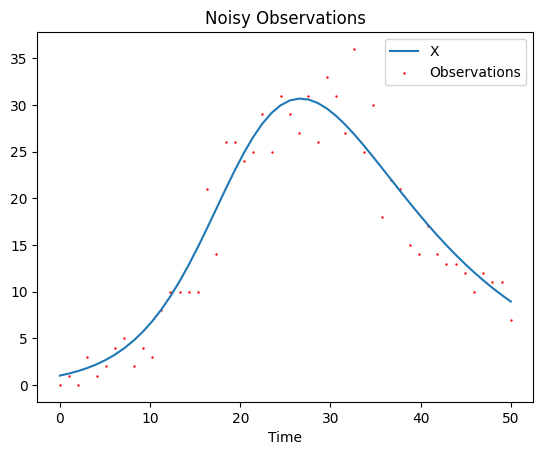

In [4]:
plt.title('Noisy Observations')
plt.plot(t_vec,full_state[:,1],label = 'X')
plt.scatter(t_vec,observations,s = 0.5,color = 'red', label = 'Observations')
plt.xlabel('Time')
plt.legend()
plt.show()

Iteration 0 with ESS 99999.921875
Iteration 1 with ESS 99999.921875
Iteration 2 with ESS 99052.8203125
Iteration 3 with ESS 88235.1015625
Iteration 4 with ESS 78947.2265625
Iteration 5 with ESS 76485.3671875
Iteration 6 with ESS 61681.6484375
Iteration 7 with ESS 28710.37109375


JaxRuntimeError: INTERNAL: jaxlib/gpu/solver_handle_pool.cc:37: operation gpusolverDnCreate(&handle) failed: cuSolver internal error

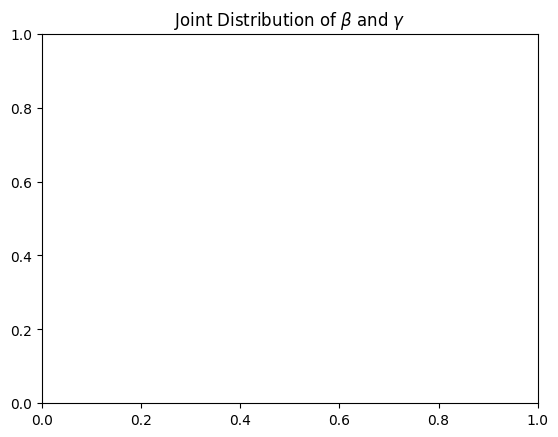

In [5]:
from algorithms.smc import ibis


def likelihood(theta, observations, m, key):
    mask = jnp.arange(observations.shape[0]) < m

    full_state = model(t_vec, jnp.array([100.0, 1.0, 0.0]), theta)

    rate = jnp.maximum(full_state[:, 1], 1e-6)
    all_log_pdfs = jax.scipy.stats.poisson.logpmf(observations, rate)

    return jnp.sum(jnp.where(mask, all_log_pdfs, 0.0))


num_particles = 100_000
dim = 2
p_init_key, rng_key = jax.random.split(rng_key)
particles = jnp.array([jnp.log(0.1), jnp.log(0.1)]) + jax.random.normal(
    p_init_key, shape=(num_particles, dim)
)

k = 5
ibis_key, key = jax.random.split(rng_key)
particles = ibis(likelihood, observations, k, particles, ibis_key)

plt.title("Joint Distribution of $\\beta$ and $\\gamma$")
plt.scatter(jnp.exp(particles[:, 0]), jnp.exp(particles[:, 1]),s = 1.0)
plt.show()


In [ ]:
print(particles)

[[-1.2203535 -2.3485003]
 [-1.2247752 -2.3210828]
 [-1.2336284 -2.3348398]
 ...
 [-1.2107716 -2.2972012]
 [-1.2025001 -2.3037348]
 [-1.2180495 -2.3492248]]
